# PCA By Hand — Two Examples

This notebook implements the two PCA examples from the *PCA By Hand* document, each solved in **two ways**:
1. **NumPy / scikit-learn** — standard scientific Python
2. **PyTorch** — using tensor operations and `torch.linalg`

---
## Steps followed (both examples)
1. Mean-center the data
2. Compute the covariance matrix
3. Compute eigenvalues & eigenvectors
4. Select principal components
5. Project (transform) the data
6. Reconstruct the data
7. Visualize

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA as skPCA

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f"NumPy  : {np.__version__}")
print(f"PyTorch: {torch.__version__}")

NumPy  : 1.24.3
PyTorch: 2.4.1


---
# Example 1 — Two Collinear Points

**Data points:** $P_1 = (-1,\,1)$ and $P_2 = (1,\,-1)$

The points lie exactly on the line $y = -x$, so PC1 captures **all** variance and PC2 captures **none**.

**Expected results (from document)**
| | Value |
|---|---|
| Covariance matrix $S$ | $\begin{bmatrix}1 & -1\\-1 & 1\end{bmatrix}$ |
| $\lambda_1$ | 2 |
| $\lambda_2$ | 0 |
| PC1 (normalized) | $[0.707,\,-0.707]^T$ |
| PC2 (normalized) | $[0.707,\;0.707]^T$ |

## 1-A  NumPy + scikit-learn

In [10]:
# ── Data ────────────────────────────────────────────────────────────────
X1 = np.array([[-1., 1.],
               [ 1.,-1.]])

print("=== Example 1 — NumPy / scikit-learn ===")
print(f"Original data:\n{X1}\n")

# ── Step 1: Mean-center ─────────────────────────────────────────────────
mean1 = X1.mean(axis=0)
X1_c  = X1 - mean1          # centered data
print(f"Feature means : {mean1}")
print(f"Centered data :\n{X1_c}\n")

# ── Step 2: Covariance matrix (ddof=1 gives sample covariance) ──────────
# With only 2 points the sample cov uses N-1=1 in denominator.
# The document computes  S = X_c^T X_c / (N-1).
S1 = np.cov(X1_c.T)         # shape (2,2)
print(f"Covariance matrix S:\n{S1}\n")

# ── Step 3: Eigenvalues & eigenvectors ──────────────────────────────────
# np.linalg.eigh returns eigenvalues in ascending order for symmetric matrices.
eigvals1_np, eigvecs1_np = np.linalg.eigh(S1)

# Sort descending so PC1 is first
idx     = np.argsort(eigvals1_np)[::-1]
eigvals1_np = eigvals1_np[idx]
eigvecs1_np = eigvecs1_np[:, idx]

print(f"Eigenvalues (desc): {eigvals1_np}")
print(f"Eigenvectors (columns = PCs):\n{eigvecs1_np}\n")

# ── Step 4: Variance explained ─────────────────────────────────────────
total_var = eigvals1_np.sum()
var_explained = eigvals1_np / total_var * 100
print(f"Variance explained: PC1={var_explained[0]:.1f}%  PC2={var_explained[1]:.1f}%\n")

# ── Step 5: Project onto PC1 (1-D reduction) ───────────────────────────
pc1_np      = eigvecs1_np[:, 0]          # principal eigenvector
scores1_np  = X1_c @ eigvecs1_np         # full 2-D projection
reduced1_np = X1_c @ pc1_np.reshape(-1,1)  # 1-D scores
print(f"Projection onto all PCs (scores):\n{scores1_np}")
print(f"\n1-D scores on PC1: {reduced1_np.ravel()}\n")

# ── Step 6: Reconstruct ────────────────────────────────────────────────
X1_reconstructed = reduced1_np @ pc1_np.reshape(1,-1) + mean1
print(f"Reconstructed data (from PC1 only):\n{X1_reconstructed}")
print(f"Reconstruction error (MSE): {np.mean((X1 - X1_reconstructed)**2):.6f}")

# ── Step 7: sklearn cross-check ────────────────────────────────────────
print("\n--- sklearn cross-check ---")
sk1 = skPCA(n_components=2)
sk1.fit(X1)
print(f"sklearn components (rows):\n{sk1.components_}")
print(f"sklearn explained variance ratio: {sk1.explained_variance_ratio_}")

=== Example 1 — NumPy / scikit-learn ===
Original data:
[[-1.  1.]
 [ 1. -1.]]

Feature means : [0. 0.]
Centered data :
[[-1.  1.]
 [ 1. -1.]]

Covariance matrix S:
[[ 2. -2.]
 [-2.  2.]]

Eigenvalues (desc): [4. 0.]
Eigenvectors (columns = PCs):
[[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]

Variance explained: PC1=100.0%  PC2=0.0%

Projection onto all PCs (scores):
[[ 1.41421356  0.        ]
 [-1.41421356  0.        ]]

1-D scores on PC1: [ 1.41421356 -1.41421356]

Reconstructed data (from PC1 only):
[[-1.  1.]
 [ 1. -1.]]
Reconstruction error (MSE): 0.000000

--- sklearn cross-check ---
sklearn components (rows):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
sklearn explained variance ratio: [1.00000000e+00 2.81351049e-34]


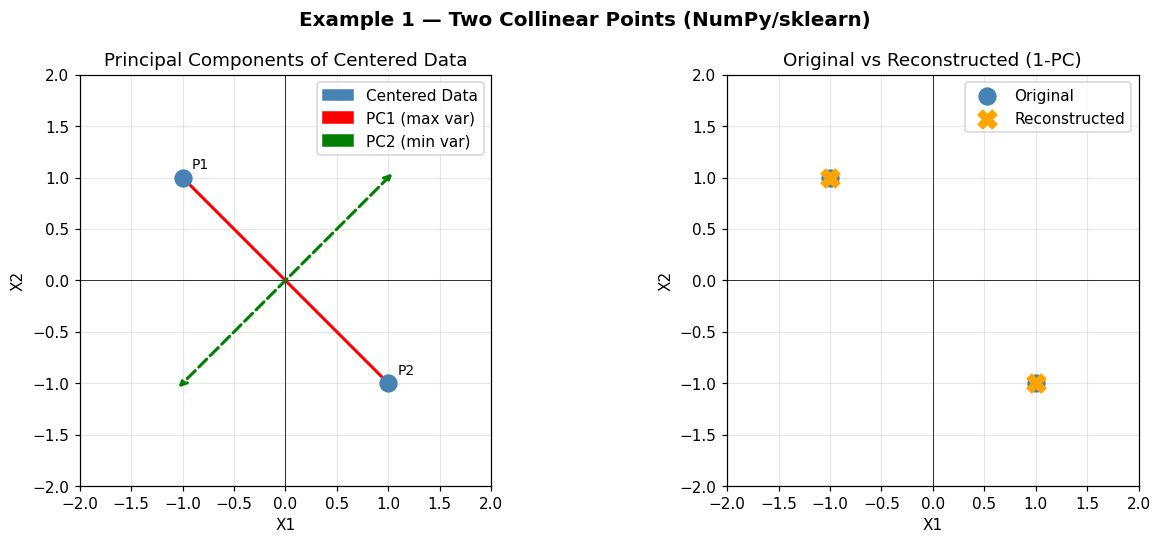

In [11]:
# ── Visualization — Example 1 (NumPy) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Example 1 — Two Collinear Points (NumPy/sklearn)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.set_title('Principal Components of Centered Data')
ax.scatter(X1_c[:,0], X1_c[:,1], color='steelblue', s=120, zorder=5, label='Centered Data')
for i, (xx, yy) in enumerate(X1_c):
    ax.annotate(f'P{i+1}', (xx, yy), textcoords='offset points', xytext=(6,6), fontsize=9)

scale = 1.5
v1, v2 = eigvecs1_np[:,0], eigvecs1_np[:,1]
ax.annotate('', xy=scale*v1, xytext=-scale*v1,
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.annotate('', xy=scale*v2, xytext=-scale*v2,
            arrowprops=dict(arrowstyle='<->', color='green', lw=2, linestyle='dashed'))

ax.axhline(0, color='k', linewidth=0.5); ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlim(-2,2); ax.set_ylim(-2,2); ax.set_aspect('equal')
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Centered Data'),
    mpatches.Patch(color='red',       label='PC1 (max var)'),
    mpatches.Patch(color='green',     label='PC2 (min var)')])
ax.set_xlabel('X1'); ax.set_ylabel('X2')

ax = axes[1]
ax.set_title('Original vs Reconstructed (1-PC)')
ax.scatter(X1[:,0], X1[:,1], color='steelblue', s=120, zorder=5, label='Original')
ax.scatter(X1_reconstructed[:,0], X1_reconstructed[:,1],
           color='orange', marker='X', s=150, zorder=6, label='Reconstructed')
for i in range(len(X1)):
    ax.plot([X1[i,0], X1_reconstructed[i,0]],
            [X1[i,1], X1_reconstructed[i,1]], 'gray', lw=1, linestyle='--')
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.set_xlim(-2,2); ax.set_ylim(-2,2); ax.set_aspect('equal')
ax.legend(); ax.set_xlabel('X1'); ax.set_ylabel('X2')

plt.tight_layout()
plt.show()

## 1-B  PyTorch

In [12]:
# ── Data ────────────────────────────────────────────────────────────────
X1_t = torch.tensor([[-1., 1.],
                      [ 1.,-1.]], dtype=torch.float64)

print("=== Example 1 — PyTorch ===")

# ── Step 1: Mean-center ─────────────────────────────────────────────────
mean1_t = X1_t.mean(dim=0)
X1_c_t  = X1_t - mean1_t
print(f"Feature means : {mean1_t.numpy()}")
print(f"Centered data :\n{X1_c_t.numpy()}\n")

# ── Step 2: Covariance matrix ───────────────────────────────────────────
# Manual: S = X_c^T @ X_c / (N-1)
N1 = X1_c_t.shape[0]
S1_t = (X1_c_t.T @ X1_c_t) / (N1 - 1)
print(f"Covariance matrix S (PyTorch):\n{S1_t.numpy()}\n")

# ── Step 3: Eigendecomposition ──────────────────────────────────────────
# torch.linalg.eigh returns (eigenvalues ascending, eigenvectors as columns)
eigvals1_t, eigvecs1_t = torch.linalg.eigh(S1_t)

# Sort descending
idx_t       = torch.argsort(eigvals1_t, descending=True)
eigvals1_t  = eigvals1_t[idx_t]
eigvecs1_t  = eigvecs1_t[:, idx_t]

print(f"Eigenvalues (desc): {eigvals1_t.numpy()}")
print(f"Eigenvectors (columns = PCs):\n{eigvecs1_t.numpy()}\n")

# ── Step 4: Variance explained ─────────────────────────────────────────
total_var_t   = eigvals1_t.sum()
var_exp_t     = eigvals1_t / total_var_t * 100
print(f"Variance explained: PC1={var_exp_t[0].item():.1f}%  PC2={var_exp_t[1].item():.1f}%\n")

# ── Step 5: Project ────────────────────────────────────────────────────
pc1_t        = eigvecs1_t[:, 0]
scores1_t    = X1_c_t @ eigvecs1_t          # full 2-D scores
reduced1_t   = X1_c_t @ pc1_t.unsqueeze(1) # 1-D score
print(f"Scores (2-D projection):\n{scores1_t.numpy()}")
print(f"\n1-D scores on PC1: {reduced1_t.squeeze().numpy()}\n")

# ── Step 6: Reconstruct ────────────────────────────────────────────────
X1_rec_t = reduced1_t @ pc1_t.unsqueeze(0) + mean1_t
print(f"Reconstructed data:\n{X1_rec_t.numpy()}")
mse_t = ((X1_t - X1_rec_t)**2).mean()
print(f"Reconstruction MSE: {mse_t.item():.6f}")

=== Example 1 — PyTorch ===
Feature means : [0. 0.]
Centered data :
[[-1.  1.]
 [ 1. -1.]]

Covariance matrix S (PyTorch):
[[ 2. -2.]
 [-2.  2.]]

Eigenvalues (desc): [4. 0.]
Eigenvectors (columns = PCs):
[[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]

Variance explained: PC1=100.0%  PC2=0.0%

Scores (2-D projection):
[[ 1.41421356  0.        ]
 [-1.41421356  0.        ]]

1-D scores on PC1: [ 1.41421356 -1.41421356]

Reconstructed data:
[[-1.  1.]
 [ 1. -1.]]
Reconstruction MSE: 0.000000


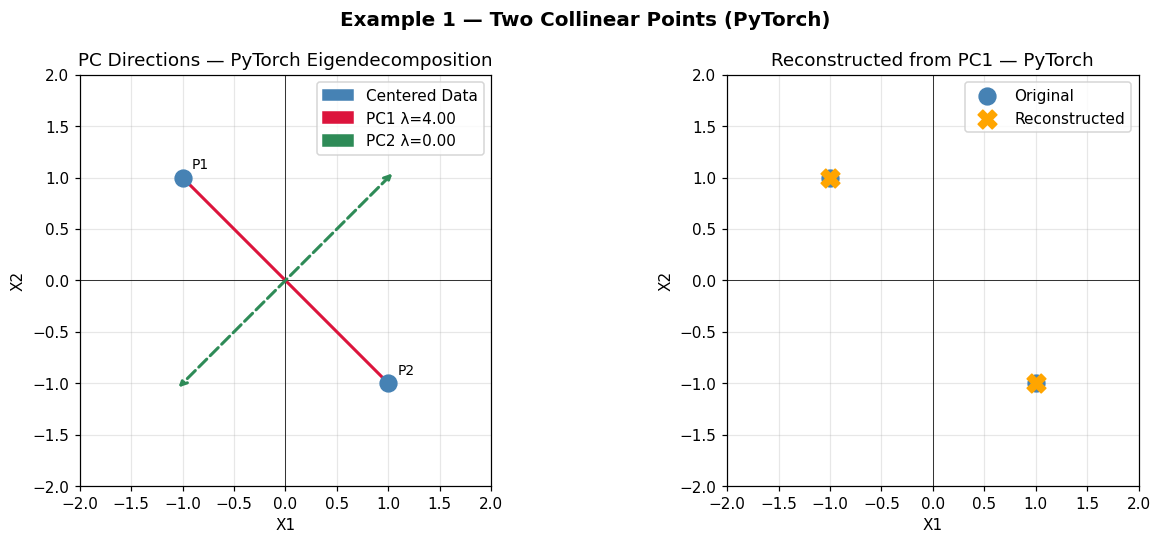

In [13]:
# ── Visualization — Example 1 (PyTorch) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Example 1 — Two Collinear Points (PyTorch)', fontsize=13, fontweight='bold')

X1_c_np  = X1_c_t.numpy()
X1_np    = X1_t.numpy()
X1_rec   = X1_rec_t.numpy()
ev1      = eigvecs1_t.numpy()

ax = axes[0]
ax.set_title('PC Directions — PyTorch Eigendecomposition')
ax.scatter(X1_c_np[:,0], X1_c_np[:,1], color='steelblue', s=120, zorder=5)
for i, (xx, yy) in enumerate(X1_c_np):
    ax.annotate(f'P{i+1}', (xx, yy), textcoords='offset points', xytext=(6,6), fontsize=9)
scale = 1.5
ax.annotate('', xy=scale*ev1[:,0], xytext=-scale*ev1[:,0],
            arrowprops=dict(arrowstyle='<->', color='crimson', lw=2))
ax.annotate('', xy=scale*ev1[:,1], xytext=-scale*ev1[:,1],
            arrowprops=dict(arrowstyle='<->', color='seagreen', lw=2, linestyle='dashed'))
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.set_xlim(-2,2); ax.set_ylim(-2,2); ax.set_aspect('equal')
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Centered Data'),
    mpatches.Patch(color='crimson',   label=f'PC1 λ={eigvals1_t[0].item():.2f}'),
    mpatches.Patch(color='seagreen',  label=f'PC2 λ={eigvals1_t[1].item():.2f}')])
ax.set_xlabel('X1'); ax.set_ylabel('X2')

ax = axes[1]
ax.set_title('Reconstructed from PC1 — PyTorch')
ax.scatter(X1_np[:,0], X1_np[:,1], color='steelblue', s=120, zorder=5, label='Original')
ax.scatter(X1_rec[:,0], X1_rec[:,1], color='orange', marker='X', s=150, zorder=6, label='Reconstructed')
for i in range(len(X1_np)):
    ax.plot([X1_np[i,0], X1_rec[i,0]], [X1_np[i,1], X1_rec[i,1]], 'gray', lw=1, ls='--')
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.set_xlim(-2,2); ax.set_ylim(-2,2); ax.set_aspect('equal')
ax.legend(); ax.set_xlabel('X1'); ax.set_ylabel('X2')

plt.tight_layout()
plt.show()

---
# Example 2 — Five Non-Collinear Points

**Data points (already centered):**  
$(-2,-1),\; (-1,-1),\; (0,0),\; (1,1),\; (2,1)$

These points are roughly diagonal but have **noise** (not all on a perfect line), so PC2 captures a small but non-zero fraction of variance.

**Expected results (from document)**
| | Value |
|---|---|
| Covariance matrix $S$ | $\begin{bmatrix}2.5 & 1.5\\1.5 & 1.0\end{bmatrix}$ |
| $\lambda_1$ | $\approx 3.43$ |
| $\lambda_2$ | $\approx 0.07$ |
| PC1 | $[0.85,\;0.53]^T$ |
| PC2 | $[-0.53,\;0.85]^T$ |
| PC1 variance explained | $\approx 98\%$ |
| PC2 variance explained | $\approx 2\%$ |

## 2-A  NumPy + scikit-learn

In [14]:
# ── Data ────────────────────────────────────────────────────────────────
X2 = np.array([[-2.,-1.],
               [-1.,-1.],
               [ 0., 0.],
               [ 1., 1.],
               [ 2., 1.]])

print("=== Example 2 — NumPy / scikit-learn ===")
print(f"Original data:\n{X2}\n")

# ── Step 1: Mean-center ─────────────────────────────────────────────────
mean2 = X2.mean(axis=0)
X2_c  = X2 - mean2
print(f"Feature means : {mean2}")
print(f"Centered data :\n{X2_c}\n")

# ── Step 2: Covariance matrix ───────────────────────────────────────────
S2 = np.cov(X2_c.T)   # ddof=1 (sample covariance)
print(f"Covariance matrix S:\n{S2}\n")

# ── Step 3: Eigenvalues & eigenvectors ──────────────────────────────────
eigvals2_np, eigvecs2_np = np.linalg.eigh(S2)
idx2 = np.argsort(eigvals2_np)[::-1]
eigvals2_np = eigvals2_np[idx2]
eigvecs2_np = eigvecs2_np[:, idx2]

print(f"Eigenvalues (desc): {eigvals2_np}")
print(f"Eigenvectors (columns = PCs):\n{eigvecs2_np}\n")

# ── Step 4: Variance explained ─────────────────────────────────────────
total2   = eigvals2_np.sum()
var_exp2 = eigvals2_np / total2 * 100
print(f"Variance explained: PC1={var_exp2[0]:.1f}%  PC2={var_exp2[1]:.1f}%\n")

# ── Step 5: Project onto both PCs ──────────────────────────────────────
scores2_np   = X2_c @ eigvecs2_np           # N×2 (full PCA space)
reduced2_np  = scores2_np[:, [0]]           # keep only PC1
print(f"Full PCA scores (PC1, PC2):\n{scores2_np}\n")

# ── Step 6: Reconstruct from PC1 only ─────────────────────────────────
X2_reconstructed = reduced2_np @ eigvecs2_np[:,0:1].T + mean2
print(f"Reconstructed data (from PC1 only):\n{X2_reconstructed}")
print(f"Reconstruction MSE : {np.mean((X2 - X2_reconstructed)**2):.6f}")

# ── Manual check of point P5=(2,1) transform ───────────────────────────
p5 = X2_c[4]
p5_pc1 = p5 @ eigvecs2_np[:,0]
p5_pc2 = p5 @ eigvecs2_np[:,1]
print(f"\nPoint P5 centered: {p5}")
print(f"P5 → PC1 coord : {p5_pc1:.4f}  (doc: 2.23)")
print(f"P5 → PC2 coord : {p5_pc2:.4f}  (doc: -0.21)")

# ── sklearn cross-check ────────────────────────────────────────────────
print("\n--- sklearn cross-check ---")
sk2 = skPCA(n_components=2)
sk2.fit(X2)
print(f"sklearn explained variance ratio: {sk2.explained_variance_ratio_}")
print(f"sklearn components:\n{sk2.components_}")

=== Example 2 — NumPy / scikit-learn ===
Original data:
[[-2. -1.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  1.]]

Feature means : [0. 0.]
Centered data :
[[-2. -1.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  1.]]

Covariance matrix S:
[[2.5 1.5]
 [1.5 1. ]]

Eigenvalues (desc): [3.42705098 0.07294902]
Eigenvectors (columns = PCs):
[[-0.85065081  0.52573111]
 [-0.52573111 -0.85065081]]

Variance explained: PC1=97.9%  PC2=2.1%

Full PCA scores (PC1, PC2):
[[ 2.22703273 -0.20081142]
 [ 1.37638192  0.3249197 ]
 [ 0.          0.        ]
 [-1.37638192 -0.3249197 ]
 [-2.22703273  0.20081142]]

Reconstructed data (from PC1 only):
[[-1.89442719 -1.17082039]
 [-1.17082039 -0.7236068 ]
 [ 0.          0.        ]
 [ 1.17082039  0.7236068 ]
 [ 1.89442719  1.17082039]]
Reconstruction MSE : 0.029180

Point P5 centered: [2. 1.]
P5 → PC1 coord : -2.2270  (doc: 2.23)
P5 → PC2 coord : 0.2008  (doc: -0.21)

--- sklearn cross-check ---
sklearn explained variance ratio: [0.97915742 0.02084258]
sklearn componen

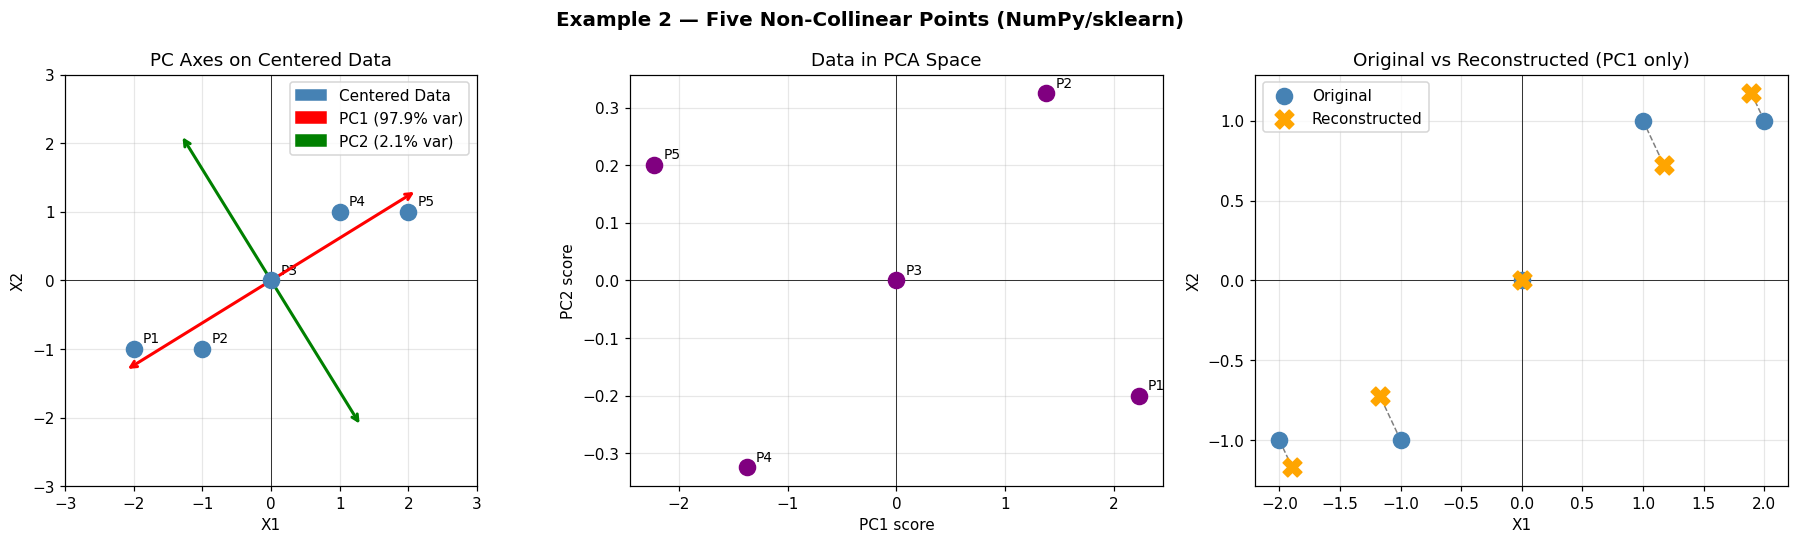

In [15]:
# ── Visualization — Example 2 (NumPy) ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Example 2 — Five Non-Collinear Points (NumPy/sklearn)', fontsize=13, fontweight='bold')

# --- Plot A: Original data with PC axes ---
ax = axes[0]
ax.set_title('PC Axes on Centered Data')
ax.scatter(X2_c[:,0], X2_c[:,1], color='steelblue', s=110, zorder=5)
labels = ['P1','P2','P3','P4','P5']
for i, (xx, yy) in enumerate(X2_c):
    ax.annotate(labels[i], (xx, yy), textcoords='offset points', xytext=(6,4), fontsize=9)

scale2 = 2.5
v1, v2 = eigvecs2_np[:,0], eigvecs2_np[:,1]
for v, col, lbl in [(v1,'red','PC1 (98% var)'), (v2,'green','PC2 (2% var)')]:
    ax.annotate('', xy=scale2*v, xytext=-scale2*v,
                arrowprops=dict(arrowstyle='<->', color=col, lw=2))
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_aspect('equal')
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Centered Data'),
    mpatches.Patch(color='red',       label=f'PC1 ({var_exp2[0]:.1f}% var)'),
    mpatches.Patch(color='green',     label=f'PC2 ({var_exp2[1]:.1f}% var)')])
ax.set_xlabel('X1'); ax.set_ylabel('X2')

# --- Plot B: PCA space (scores) ---
ax = axes[1]
ax.set_title('Data in PCA Space')
ax.scatter(scores2_np[:,0], scores2_np[:,1], color='purple', s=110, zorder=5)
for i, (sx, sy) in enumerate(scores2_np):
    ax.annotate(labels[i], (sx, sy), textcoords='offset points', xytext=(6,4), fontsize=9)
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.set_xlabel('PC1 score'); ax.set_ylabel('PC2 score')

# --- Plot C: Original vs Reconstructed ---
ax = axes[2]
ax.set_title('Original vs Reconstructed (PC1 only)')
ax.scatter(X2[:,0], X2[:,1], color='steelblue', s=110, zorder=5, label='Original')
ax.scatter(X2_reconstructed[:,0], X2_reconstructed[:,1],
           color='orange', marker='X', s=150, zorder=6, label='Reconstructed')
for i in range(len(X2)):
    ax.plot([X2[i,0], X2_reconstructed[i,0]],
            [X2[i,1], X2_reconstructed[i,1]], 'gray', lw=1, ls='--')
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.set_xlabel('X1'); ax.set_ylabel('X2')
ax.legend()

plt.tight_layout()
plt.show()

## 2-B  PyTorch

In [8]:
# ── Data ────────────────────────────────────────────────────────────────
X2_t = torch.tensor([[-2.,-1.],
                      [-1.,-1.],
                      [ 0., 0.],
                      [ 1., 1.],
                      [ 2., 1.]], dtype=torch.float64)

print("=== Example 2 — PyTorch ===")

# ── Step 1: Mean-center ─────────────────────────────────────────────────
mean2_t = X2_t.mean(dim=0)
X2_c_t  = X2_t - mean2_t
print(f"Feature means : {mean2_t.numpy()}")
print(f"Centered data :\n{X2_c_t.numpy()}\n")

# ── Step 2: Covariance matrix ───────────────────────────────────────────
N2   = X2_c_t.shape[0]
S2_t = (X2_c_t.T @ X2_c_t) / (N2 - 1)
print(f"Covariance matrix S (PyTorch):\n{S2_t.numpy()}\n")

# ── Step 3: Eigendecomposition ──────────────────────────────────────────
eigvals2_t, eigvecs2_t = torch.linalg.eigh(S2_t)

idx2_t      = torch.argsort(eigvals2_t, descending=True)
eigvals2_t  = eigvals2_t[idx2_t]
eigvecs2_t  = eigvecs2_t[:, idx2_t]

print(f"Eigenvalues (desc): {eigvals2_t.numpy()}")
print(f"Eigenvectors:\n{eigvecs2_t.numpy()}\n")

# ── Step 4: Variance explained ─────────────────────────────────────────
total2_t   = eigvals2_t.sum()
var_exp2_t = eigvals2_t / total2_t * 100
print(f"Variance explained: PC1={var_exp2_t[0].item():.1f}%  PC2={var_exp2_t[1].item():.1f}%\n")

# ── Step 5: Project ────────────────────────────────────────────────────
scores2_t   = X2_c_t @ eigvecs2_t          # N×2
reduced2_t  = scores2_t[:, 0:1]            # keep PC1 only
print(f"PCA scores:\n{scores2_t.numpy()}\n")

# ── Step 6: Reconstruct ────────────────────────────────────────────────
X2_rec_t = reduced2_t @ eigvecs2_t[:, 0:1].T + mean2_t
mse2_t   = ((X2_t - X2_rec_t)**2).mean()
print(f"Reconstructed data:\n{X2_rec_t.numpy()}")
print(f"Reconstruction MSE: {mse2_t.item():.6f}")

# ── Alternative: torch.pca_lowrank (SVD-based, numerically stable) ─────
print("\n--- torch.pca_lowrank cross-check ---")
# pca_lowrank works on centered data; returns (U, S, V) where V = loadings
U, S_svd, V = torch.pca_lowrank(X2_c_t, q=2, center=False)
# Singular values → explained variance
var_svd = (S_svd**2) / (N2 - 1)
var_svd_pct = var_svd / var_svd.sum() * 100
print(f"pca_lowrank variance explained: PC1={var_svd_pct[0].item():.1f}%  PC2={var_svd_pct[1].item():.1f}%")
print(f"pca_lowrank loadings (V):\n{V.numpy()}")

=== Example 2 — PyTorch ===
Feature means : [0. 0.]
Centered data :
[[-2. -1.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  1.]]

Covariance matrix S (PyTorch):
[[2.5 1.5]
 [1.5 1. ]]

Eigenvalues (desc): [3.42705098 0.07294902]
Eigenvectors:
[[-0.85065081  0.52573111]
 [-0.52573111 -0.85065081]]

Variance explained: PC1=97.9%  PC2=2.1%

PCA scores:
[[ 2.22703273 -0.20081142]
 [ 1.37638192  0.3249197 ]
 [ 0.          0.        ]
 [-1.37638192 -0.3249197 ]
 [-2.22703273  0.20081142]]

Reconstructed data:
[[-1.89442719 -1.17082039]
 [-1.17082039 -0.7236068 ]
 [ 0.          0.        ]
 [ 1.17082039  0.7236068 ]
 [ 1.89442719  1.17082039]]
Reconstruction MSE: 0.029180

--- torch.pca_lowrank cross-check ---
pca_lowrank variance explained: PC1=97.9%  PC2=2.1%
pca_lowrank loadings (V):
[[-0.85065081 -0.52573111]
 [-0.52573111  0.85065081]]


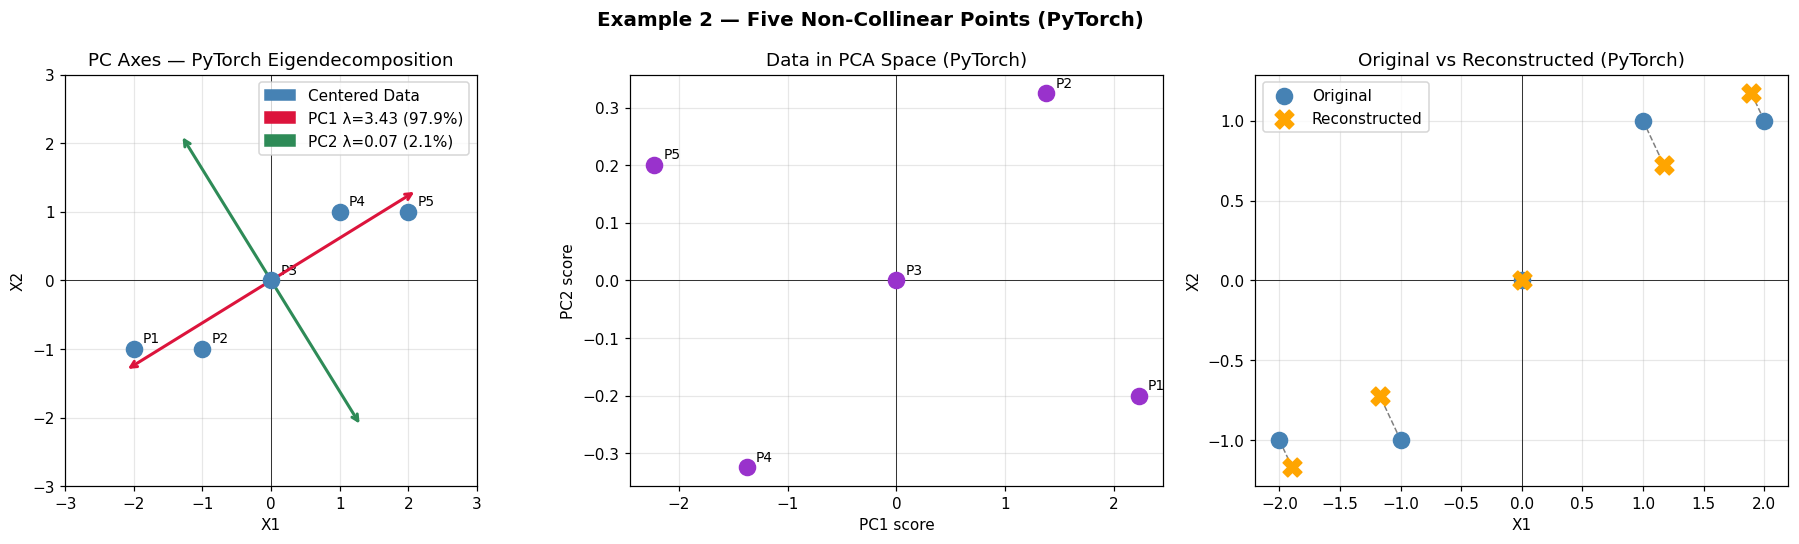

In [9]:
# ── Visualization — Example 2 (PyTorch) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Example 2 — Five Non-Collinear Points (PyTorch)', fontsize=13, fontweight='bold')

X2_c_np2  = X2_c_t.numpy()
X2_np2    = X2_t.numpy()
X2_rec2   = X2_rec_t.numpy()
scores2   = scores2_t.numpy()
ev2       = eigvecs2_t.numpy()
evals2    = eigvals2_t.numpy()
vexp2     = var_exp2_t.numpy()

# --- Plot A: PC axes on centered data ---
ax = axes[0]
ax.set_title('PC Axes — PyTorch Eigendecomposition')
ax.scatter(X2_c_np2[:,0], X2_c_np2[:,1], color='steelblue', s=110, zorder=5)
for i, (xx, yy) in enumerate(X2_c_np2):
    ax.annotate(f'P{i+1}', (xx, yy), textcoords='offset points', xytext=(6,4), fontsize=9)
scale2 = 2.5
for v, col in [(ev2[:,0],'crimson'), (ev2[:,1],'seagreen')]:
    ax.annotate('', xy=scale2*v, xytext=-scale2*v,
                arrowprops=dict(arrowstyle='<->', color=col, lw=2))
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_aspect('equal')
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Centered Data'),
    mpatches.Patch(color='crimson',   label=f'PC1 λ={evals2[0]:.2f} ({vexp2[0]:.1f}%)'),
    mpatches.Patch(color='seagreen',  label=f'PC2 λ={evals2[1]:.2f} ({vexp2[1]:.1f}%)')])
ax.set_xlabel('X1'); ax.set_ylabel('X2')

# --- Plot B: PCA space ---
ax = axes[1]
ax.set_title('Data in PCA Space (PyTorch)')
ax.scatter(scores2[:,0], scores2[:,1], color='darkorchid', s=110, zorder=5)
for i, (sx, sy) in enumerate(scores2):
    ax.annotate(f'P{i+1}', (sx, sy), textcoords='offset points', xytext=(6,4), fontsize=9)
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.set_xlabel('PC1 score'); ax.set_ylabel('PC2 score')

# --- Plot C: Original vs Reconstructed ---
ax = axes[2]
ax.set_title('Original vs Reconstructed (PyTorch)')
ax.scatter(X2_np2[:,0], X2_np2[:,1], color='steelblue', s=110, zorder=5, label='Original')
ax.scatter(X2_rec2[:,0], X2_rec2[:,1], color='orange', marker='X', s=150, zorder=6, label='Reconstructed')
for i in range(len(X2_np2)):
    ax.plot([X2_np2[i,0], X2_rec2[i,0]], [X2_np2[i,1], X2_rec2[i,1]], 'gray', lw=1, ls='--')
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.set_xlabel('X1'); ax.set_ylabel('X2')
ax.legend()

plt.tight_layout()
plt.show()

---
# Summary

| | Example 1 | Example 2 |
|---|---|---|
| **Points** | 2 (collinear) | 5 (roughly diagonal, noisy) |
| **Covariance S** | `[[1,-1],[-1,1]]` | `[[2.5,1.5],[1.5,1.0]]` |
| **λ₁** | 2.00 | ≈ 3.43 |
| **λ₂** | 0.00 | ≈ 0.07 |
| **PC1 var explained** | 100% | ≈ 98% |
| **PC2 var explained** | 0% | ≈ 2% |
| **Reconstruction MSE (1 PC)** | 0.0 | small but > 0 |

**Key takeaways:**
- When data is perfectly collinear (Ex. 1), λ₂ = 0 and a single PC gives **perfect** reconstruction.
- When data has noise/width (Ex. 2), λ₂ > 0, and dropping PC2 introduces a small but measurable error.
- NumPy (`np.linalg.eigh`) and PyTorch (`torch.linalg.eigh` / `torch.pca_lowrank`) give numerically identical results.